In [32]:
import numpy as np#load ice cube data
from scipy.optimize import minimize
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [2]:
files=["IC40_exp_new.csv","IC59_exp_new.csv","IC79_exp_new.csv","IC86_I_exp_new.csv","IC86_II_exp_new.csv", 
       "IC86_III_exp_new.csv","IC86_IV_exp_new.csv","IC86_V_exp_new.csv","IC86_VI_exp_new.csv",
       "IC86_VII_exp_new.csv"]

In [3]:
data=np.loadtxt("IC40_exp_new.csv")
for name in files[1:]:#indexing the list
    da=np.loadtxt(name)
    data=np.vstack((data,da))#load everyfile
mjd,log10_E,Ang_err,RA,Dec,Azim,Zenith=data.T
len(RA)
    

1134431

In [4]:
fields=[log10_E,RA,Dec,Ang_err]
print(Ang_err)
iceang=fields[3]

[0.48 0.62 0.56 ... 0.3  0.21 0.25]


In [6]:
ice_ra_deg=(fields[1])
ice_dec_deg=(fields[2])
print(ice_ra_deg)
print(ice_dec_deg)

[203.024  75.024  97.501 ... 308.127 332.199 213.309]
[ 16.76  -13.371  11.29  ...  42.543  44.72    4.708]


In [7]:
np.random.seed(0)
N=1000
random_ra=np.random.uniform(0,360,N)
#print(random_ra)
random_dec=np.random.uniform(np.sin(np.radians(-85)),np.sin(np.radians(85)),N)
random_dec = np.degrees(np.arcsin(random_dec))

#print(random_dec)

In [30]:
declcut = 5 
band = 5     
def angular_separation(ra1, dec1, ra2, dec2):
    delta_ra = ra1 - ra2
    return np.arccos(np.sin(dec1) * np.sin(dec2) + np.cos(dec1) * np.cos(dec2) * np.cos(delta_ra))
def sig(ra_rand_deg,dec_rand_deg,ra_rand_rad,dec_rand_rad,ice_ra1_rad,ice_dec1_rad,iceang,declcut):
        decdiff=np.abs(ice_dec_deg-dec_rand_deg)
        nuind=np.nonzero(decdiff < declcut)
        sg=np.radians(iceang[nuind])**2
        Ang_sep1=(np.arccos((np.sin(ice_dec1_rad[nuind])*np.sin(dec_rand_rad)+np.cos(ice_dec1_rad[nuind])*np.cos(dec_rand_rad)*np.cos(ice_ra1_rad[nuind]-ra_rand_rad))))**2
        return ((np.exp(-1*Ang_sep1/(2*sg)))/(2*np.pi*sg))
def bgs(dec_rand_deg, twopi = True):
        if twopi == True:
            s_ang = (np.sin(np.radians(dec_rand_deg + band)) - np.sin(np.radians(dec_rand_deg- band)))*(2 * np.pi)
            return 1/s_ang
        else:
            s_ang = (np.sin(np.deg2rad(dec_rand_rad + band)) - np.sin(np.deg2rad(dec_rand_rad- band)))
            return 1/s_ang

def P(x, N, S, B):
    nsN = x / N
    return nsN * S + (1 - nsN) * B

def TS(x, N, S, B):
    return 2 * np.sum(np.log(P(x, N, S, B) / B))
def ns_for_TSmax(dec_rand_deg,ra_rand_rad,dec_rand_rad,ice_ra1_rad,ice_dec1_rad,iceang, declcut, band):
        B= bgs(dec_rand_deg, twopi = True)
        S =sig(ra_rand_deg,dec_rand_deg,ra_rand_rad,dec_rand_rad,ice_ra1_rad,ice_dec1_rad,iceang,declcut)
        decdiff=np.abs(ice_dec_deg-dec_rand_deg)
        nuind=np.nonzero(decdiff < declcut)
        N = len(nuind[0])
        if N == 0:
            return 0, 0, 0
        nll = lambda x: -TS(x,N,S,B)
        soln = minimize(nll,6,bounds=((0,None),))
        ns = float(soln.x)
        TS_val = TS(ns, N, S, B)
        return ns,N,TS_val

ice_ra1_rad = np.radians(ice_ra_deg)
ice_dec1_rad = np.radians(ice_dec_deg)
Ts_values = []
sqrt_TS=[]
for i in range(0, 1000):
    ra_rand_deg = random_ra[i]
    dec_rand_deg = random_dec[i]
    ra_rand_rad = np.radians(ra_rand_deg)
    dec_rand_rad = np.radians(dec_rand_deg)
    Ts_values.append(TS_value)
    sqrt_TS.append(np.sqrt(TS_value))
    ns, N, TS_value = ns_for_TSmax(dec_rand_deg,ra_rand_rad,dec_rand_rad,ice_ra1_rad,ice_dec1_rad,iceang, declcut, band)
    print(i, N, ns, TS_value, sep="|")
    

0|149795|1.0656221514849964e-10|1.3276046928389502e-11
1|14206|0.0|0.0
2|121808|0.0|0.0
3|107438|19.137676882325582|2.2845439502069405
4|30544|6.443904609555999|2.299407931656333
5|58126|13.552078790943641|2.2010701960215533
6|164959|2.6090506160802134|0.0546721529475277
7|24727|0.39006505780131606|0.00985452513451203
8|67997|0.0|0.0
9|34693|0.0|0.0
10|154740|21.68965312807962|2.9407996731062873
11|47451|4.258113944023999|0.9416346412620511
12|76124|0.0|0.0
13|99550|0.0|0.0
14|20715|0.0|0.0
15|76286|0.0|0.0
16|137048|0.0|0.0
17|71891|0.0|0.0
18|151590|0.0|0.0
19|93306|0.0|0.0
20|70347|0.8541698756113113|0.037182409955932
21|138226|0.0|0.0
22|130625|0.0|0.0
23|36801|0.0|0.0
24|85597|0.12476959582199224|0.0001092406210707669
25|66130|8.492773903326992|1.167112678229556
26|138012|10.556329840216591|0.9358277037879768
27|59827|0.0|0.0
28|11500|0.0|0.0
29|50426|7.158132702907462|1.6351194325710912
30|116821|0.0|0.0
31|39449|3.377061448546344|0.5003598899773518
32|38697|0.0|0.0
33|29506|0.0|

272|88133|9.451266184790699|0.7331905378564542
273|149784|2.241053289745682|0.03533343681016748
274|83307|0.0|0.0
275|95162|0.0|0.0
276|81021|0.0|0.0
277|76359|0.0|0.0
278|78960|0.0|0.0
279|168071|11.196763044673695|0.8433979616482722
280|119011|7.106407007212941|0.8224727590909375
281|118887|0.0|0.0
282|20890|0.0|0.0
283|46910|4.390929524353258|0.655783300521824
284|75992|6.568591031538205|1.2777244339988956
285|20032|0.0|0.0
286|52015|0.0|0.0
287|78171|0.6978955226070037|0.0281530295132448
288|33136|0.0|0.0
289|78170|0.0|0.0
290|78003|0.0|0.0
291|37508|0.0|0.0
292|67060|0.0|0.0
293|76888|0.0|0.0
294|22377|0.0|0.0
295|70683|16.517391822375355|3.0879133787510917
296|123359|1.6863986163609157e-10|8.326228595256348e-12
297|53676|0.6964672825468533|0.01911615964782034
298|11246|0.0|0.0
299|46597|3.0475932126750966|0.40363573558109644
300|61341|2.8906871769562454|0.05469744038473043
301|76033|0.0|0.0
302|82062|0.0|0.0
303|80430|2.2811123728249494|0.05127204380355116
304|117961|8.7888860920

532|59181|0.0|0.0
533|41171|3.72647469810225|0.6157432941681702
534|138564|10.30056533312186|0.8808155310240091
535|104861|0.0|0.0
536|98451|0.0|0.0
537|50841|25.818915099320883|4.591636578173622
538|79165|0.0|0.0
539|77333|5.365138113019762|1.2009188905602866
540|145921|0.0|0.0
541|109911|0.0|0.0
542|51814|5.029378647725322|0.8430678547372297
543|61345|6.991555399974998|2.7050812952803045
544|127519|14.487117573862347|2.090435580403901
545|76199|0.4233615063093466|0.005373520596951811
546|62549|0.0|0.0
547|152965|0.0|0.0
548|77387|1.7876329049041766|0.13375929058510277
549|66096|16.084227868301166|1.724774460597331
550|77858|0.0|0.0
551|8768|0.0|0.0
552|66463|0.0|0.0
553|76620|0.0|0.0
554|50134|0.5243226604617509|0.015316040182323697
555|68039|0.0|0.0
556|36551|0.0|0.0
557|77260|12.108465372144265|5.215247308667004
558|46870|7.1823874184557255|0.5986088046932696
559|31514|0.0|0.0
560|130285|0.0|0.0
561|114181|9.099758717692003|0.852326352333372
562|29910|0.0|0.0
563|161230|35.14170920

808|164530|6.003285937478056|0.1837761767857205
809|59546|1.7017555476377884|0.03082036727815092
810|108894|0.0|0.0
811|137137|0.0|0.0
812|33713|5.019680381679973|0.2504253226446189
813|32634|0.0|0.0
814|72457|0.0|0.0
815|143525|0.0|0.0
816|135165|9.787252464996078|0.8531483630111361
817|16277|9.025799399376103|3.071676677374291
818|144138|21.56320456316242|3.132558683178293
819|16614|0.0|0.0
820|74250|5.544633719955128|0.3464434009405938
821|77995|0.0|0.0
822|53598|0.0|0.0
823|83906|0.0|0.0
824|96529|0.0|0.0
825|28388|0.0|0.0
826|59389|4.393864973510204|0.22387319300508748
827|165912|0.0|0.0
828|46732|0.0|0.0
829|130314|0.0|0.0
830|77699|0.0|0.0
831|159670|23.898795726737255|3.2247365455659267
832|76416|1.613063142094521|0.06807377428704574
833|62722|0.0|0.0
834|67256|0.0|0.0
835|77818|5.435772747887176|1.1757377406573306
836|146795|5.562083922598702|0.27010146415647446
837|79639|0.0|0.0
838|50087|0.0|0.0
839|60129|0.0|0.0
840|111339|0.0|0.0
841|26826|0.0|0.0
842|58006|0.0|0.0
843|629

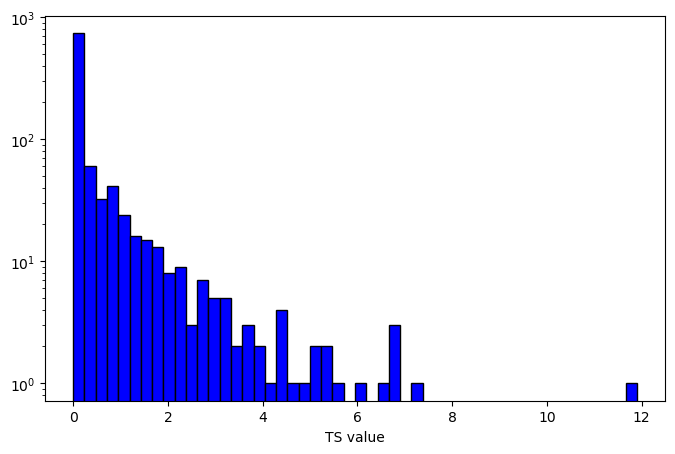

In [29]:
plt.figure(figsize=(8, 5))
plt.hist((Ts_values), bins=50,log=True, color='blue', edgecolor='black')
plt.xlabel('TS value')
#plt.ylabel('Number of sources')

plt.show()

In [97]:
f = len(random_ra)#print(p)
binnedsts, wsts = np.histogram(sqrt_TS, 10)# Creates a histogram of `sqrt_TS` with 10 bins.

#ne01 = 20
amp  = f/10.2#np.sum(binnedsts)/ne01
#binnedsts = binnedsts/amp
yerr = np.sqrt(binnedsts)
b2 = binnedsts[(binnedsts>10)]# Filters bins with more than 10 events.
yerr2 = yerr[(binnedsts>10)]# Filters y-errors for bins with >10 events.
x=0.5*(wsts[1:]+ wsts[:-1])# Computes bin centers.
x2 = x[(binnedsts>10)] # Filters bin centers with >10 events.
xerr=x[0]-wsts[0]# Error in x, assumed as bin width.
mean_guess = np.mean(sqrt_TS)
sd_guess = np.std(sqrt_TS)
print(mean_guess)
print(sd_guess)

0.3246051368611865
0.5470378076926617


In [98]:
def gaussian(x,mean,sd):
    '''Returns the gaussian PDF value at for the given mean and standard deviation'''
#    mean=0.114
    A=f/10.2
    return A*np.exp(-(x - mean) ** 2.0 / sd ** 2.0)
loggaussian = lambda x, mean, var:  np.log(gaussian(x, mean, var))
gparam, gerr = curve_fit(gaussian, x2, b2,  p0=[0.1, 0.4],sigma=yerr2, absolute_sigma=True, maxfev = 10000, method='dogbox')
gx = np.linspace(0, wsts[-1], 100)# Creates x-values for a smooth Gaussian plot.

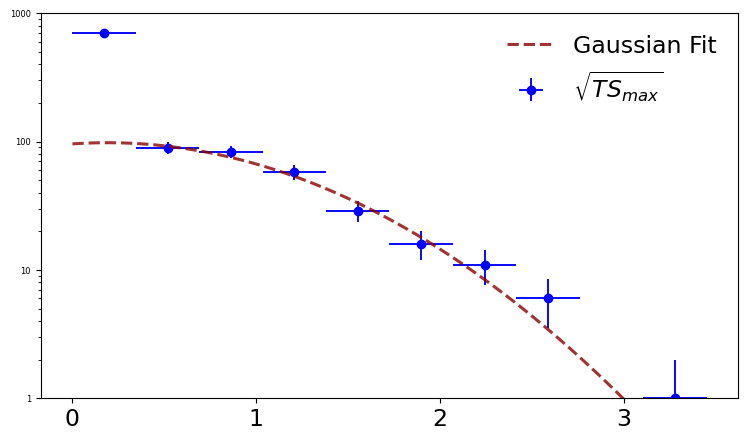

In [99]:
plt.figure(figsize=(9,5))
plt.xticks([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], [0, 1, 2, 3, 4, 5, 6, 7, 8, 9], fontsize=17)
plt.yscale('log')
plt.yticks([1, 10, 100, 1000, 10000], [1, 10, 100, 1000, 10000], fontsize=6)
plt.ylim(1, 1000)
plt.errorbar(x, binnedsts, xerr=xerr,yerr=yerr,  aa = True, barsabove = True, fmt='ob',ecolor='blue', elinewidth=1.35, label='$\sqrt{TS_{max}}$')
plt.plot(gx,gaussian(gx, gparam[0], gparam[1]),'--', alpha=0.8, label=f'Gaussian Fit', color='darkred', lw=2.2)

#plt.xlabel("$\mathbf{\sqrt{TS_{max}}}$", fontweight='bold', fontdict=font)
#plt.ylabel("No.of Events", fontweight='bold', fontdict=font)
#plt.grid(True, which='major')
legend =plt.legend(prop={'size':17}, framealpha=0)
legend.get_frame().set_facecolor('none')
#plt.savefig("outputs/sqrt(TSmax)final.jpg")
plt.show()